# Extract Hall of Fame from a Checkpoint

This notebook loads an RL4CRN checkpoint `.pkl` file and extracts the saved hall-of-fame CRNs.

In [1]:
import os
import sys
from pathlib import Path

repo_root = Path.cwd().resolve()
for candidate in [repo_root, *repo_root.parents]:
    if (candidate / 'RL4CRN').exists() and (candidate / 'apps').exists():
        repo_root = candidate
        break

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

os.environ.setdefault('MPLCONFIGDIR', '/tmp')

import cloudpickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## 1) Choose Checkpoint

In [ ]:
# Change this path to the checkpoint you want to inspect.
checkpoint_path = repo_root / 'apps' / 'habituation_hallmarks_custom_chkpt_run_4S-4.pkl'

checkpoint_path = Path(checkpoint_path)
print(checkpoint_path)
print('exists:', checkpoint_path.exists())

/local0/home/mfilo/git/GenAI-Net/apps/habituation_hallmarks_custom_chkpt_run_4S-4.pkl
exists: True


## 2) Load Payload and Extract Hall of Fame

In [3]:
with open(checkpoint_path, 'rb') as f:
    payload = cloudpickle.load(f)

print('checkpoint keys:')
for key in sorted(payload.keys()):
    print('  ', key)

hof_crns = payload.get('hall_of_fame_crns', []) or []
print('\nnumber of hall-of-fame CRNs:', len(hof_crns))

checkpoint keys:
   config
   epoch
   hall_of_fame_crns
   history
   numpy_rng
   policy_state_dict
   python_rng
   sample_hof_envs
   sample_hof_max_size
   torch_rng

number of hall-of-fame CRNs: 30


## 3) Summarize Hall of Fame

In [4]:
rows = []
for idx, crn in enumerate(hof_crns):
    info = getattr(crn, 'last_task_info', {}) or {}
    rows.append({
        'idx': idx,
        'reward': info.get('reward', np.nan),
        'reward_type': info.get('reward type', None),
        'num_reactions': len(getattr(crn, 'reactions', [])),
        'num_species': getattr(crn, 'num_species', np.nan),
        'outputs': ', '.join(getattr(crn, 'output_labels', [])),
    })

hof_df = pd.DataFrame(rows)
if len(hof_df):
    hof_df = hof_df.sort_values('reward', na_position='last').reset_index(drop=True)

hof_df

,idx,reward,reward_type,num_reactions,num_species,outputs
0,0,6.357494,habituation_hallmarks_custom,9,4,X_4
1,1,6.404746,habituation_hallmarks_custom,9,4,X_4
2,2,6.477911,habituation_hallmarks_custom,9,4,X_4
3,3,6.485193,habituation_hallmarks_custom,9,4,X_4
4,4,6.491147,habituation_hallmarks_custom,9,4,X_4
5,5,6.524252,habituation_hallmarks_custom,9,4,X_4
6,6,6.545133,habituation_hallmarks_custom,9,4,X_4
7,7,6.589105,habituation_hallmarks_custom,9,4,X_4
8,8,6.593880,habituation_hallmarks_custom,9,4,X_4
9,9,6.595183,habituation_hallmarks_custom,9,4,X_4


## 4) Inspect One CRN

In [5]:
# This is the original hall-of-fame index, not the row number after sorting above.
hof_idx = 0

crn = hof_crns[hof_idx]
print('reward:', crn.last_task_info.get('reward', None))
print('reward type:', crn.last_task_info.get('reward type', None))
print()
print(crn)

component_losses = crn.last_task_info.get('component_losses', None)
component_weights = crn.last_task_info.get('component_weights', None)
if isinstance(component_losses, dict):
    display(pd.DataFrame({
        'component': list(component_losses.keys()),
        'loss': list(component_losses.values()),
        'weight': [component_weights.get(k, 1.0) if isinstance(component_weights, dict) else 1.0 for k in component_losses.keys()],
    }))

reward: 6.357493523761629
reward type: habituation_hallmarks_custom

Inputs: ['u_1'] 
Species: ['X_1', 'X_2', 'X_3', 'X_4'] 
Output Species: ['X_4'] 
∅ ----> X_1;  [MAK(1.0, u_1)]
X_1 ----> X_1 + X_4;  [MAK(0.631569504737854)]
X_1 + X_1 ----> X_2 + X_4;  [MAK(4.3091278076171875)]
X_1 + X_4 ----> X_1;  [MAK(5.057889461517334)]
X_1 + X_4 ----> X_1 + X_3;  [MAK(0.0791698694229126)]
X_2 + X_4 ----> X_1;  [MAK(8.211370468139648)]
X_3 + X_4 ----> X_3;  [MAK(0.8968092203140259)]
X_4 + X_4 ----> X_2 + X_4;  [MAK(0.09773111343383789)]
X_4 + X_4 ----> X_3 + X_3;  [MAK(0.10049708932638168)]


,component,loss,weight
0,hallmark1,0.038065,5.0
1,hallmark2,0.009430,1.0
2,hallmark3,0.000000,1.0
3,hallmark4,0.693452,5.0
4,hallmark5,0.845238,2.0
5,hallmark6,1.000000,1.0


## 5) Render If Habituation Info Is Available

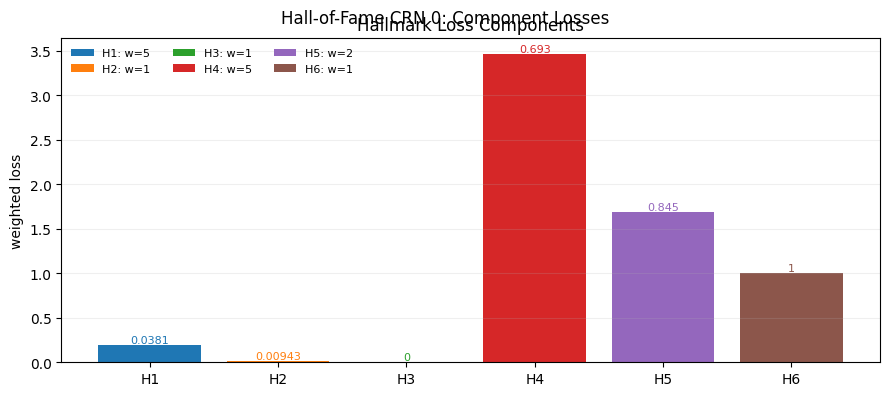

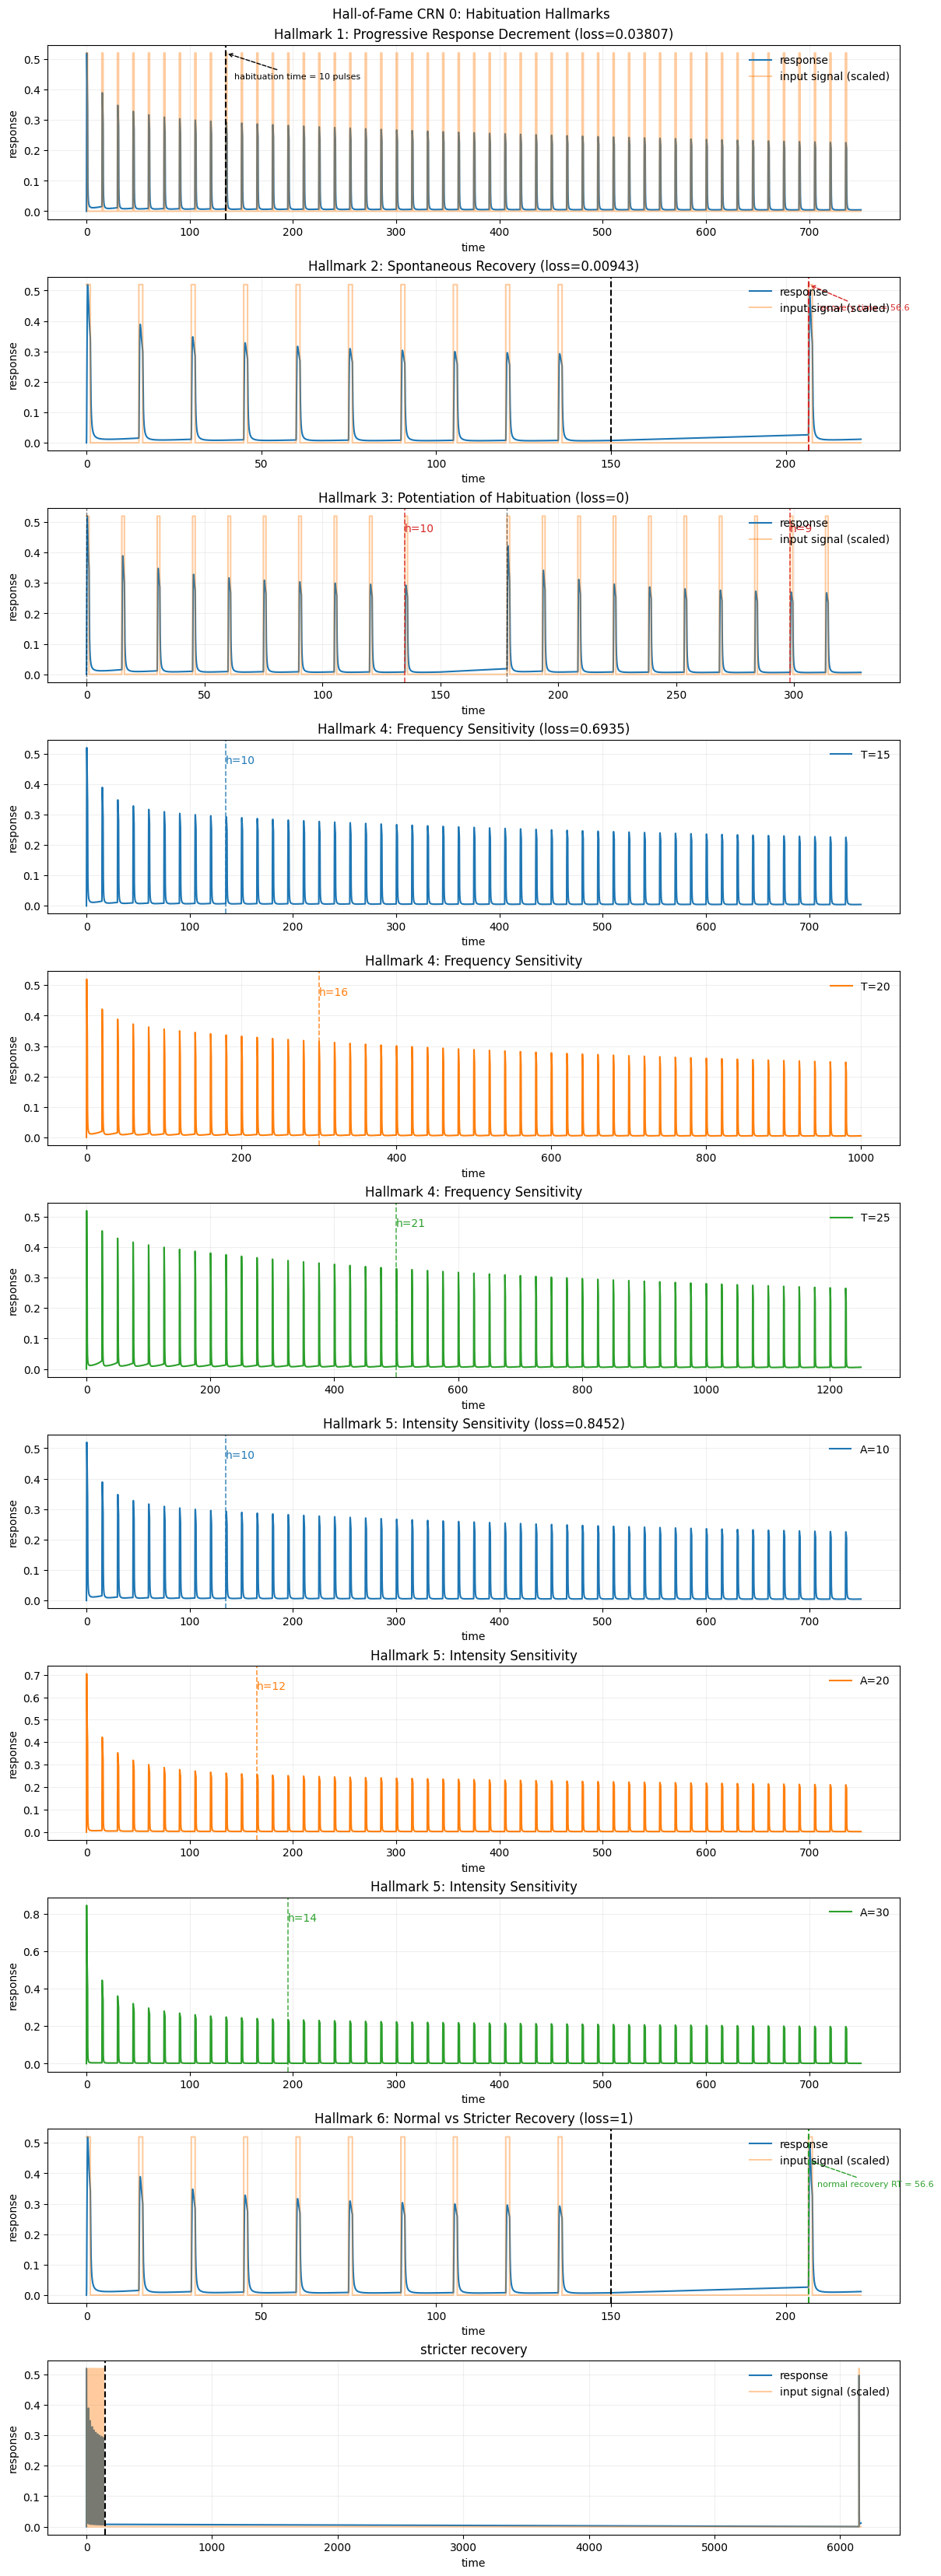

In [6]:
try:
    from apps.habituation.hallmarks_helpers import render_habituation, render_hallmark_loss_summary

    fig, _ = render_hallmark_loss_summary(crn)
    fig.suptitle(f'Hall-of-Fame CRN {hof_idx}: Component Losses')
    plt.show()

    fig, _ = render_habituation(crn)
    fig.suptitle(f'Hall-of-Fame CRN {hof_idx}: Habituation Hallmarks')
    plt.show()
except Exception as exc:
    print('Could not render habituation figures:')
    print(type(exc).__name__, exc)